# 04 — Classification: Python Implementation
**Phishing URL Detection — CS 4200 Final Project**  
**Author:** Joe Casperson

**Chapter Coverage:**  
- Chapter 8 — Programming Data Mining and Analytic Solutions (Python & R)  
- Chapter 11 — Classification

**Purpose:**  
Train and evaluate three supervised classifiers on the clean phishing dataset.  
Apply PCA for dimensionality reduction, test three train/test splits,  
and log all experiment results to MongoDB.

**Why Supervised Learning?**  
Every record in this dataset has a known ground-truth label (phishing vs benign).  
Supervised classification learns the mapping from features to labels using those  
examples. Unsupervised methods would be appropriate only if labels were unavailable  
and we were trying to discover unknown groupings — that is not our goal here.

**Models:**  
1. Logistic Regression — interpretable linear baseline  
2. Random Forest — handles nonlinear feature interactions  
3. Support Vector Machine — effective in high-dimensional spaces  

**Splits tested:** 70/30 · 80/20 · 90/10  

---

## 1. Imports and Connections

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from pymongo import MongoClient
from dotenv import load_dotenv

load_dotenv()

# MongoDB connection
mongo_client = MongoClient(os.getenv('MONGO_URI', 'mongodb://localhost:27017/'))
runs_col     = mongo_client.phishdb.model_runs
print('✓ MongoDB connected')

# Output directory
VISUALS_DIR = '../visuals'
os.makedirs(VISUALS_DIR, exist_ok=True)

# Chart style
PHISHING_COLOR = '#ef4444'
BENIGN_COLOR   = '#3b82f6'
plt.rcParams.update({
    'figure.facecolor' : '#f9fafb',
    'axes.facecolor'   : '#f9fafb',
    'axes.grid'        : True,
    'grid.color'       : '#e5e7eb',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
})
print('✓ Setup complete')

✓ MongoDB connected
✓ Setup complete


## 2. Load Clean Data and Scale Features

In [2]:
df = pd.read_csv('../data/clean/clean_urls.csv')

X = df.drop(columns=['label']).values
y = df['label'].values
feature_names = df.drop(columns=['label']).columns.tolist()

print(f'✓ Data loaded: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'  Phishing : {y.sum():,}  ({y.mean()*100:.1f}%)')
print(f'  Benign   : {(y==0).sum():,}  ({(1-y.mean())*100:.1f}%)')

✓ Data loaded: 14,823 rows × 78 features
  Phishing : 7,359  (49.6%)
  Benign   : 7,464  (50.4%)


In [4]:
# Fix infinite and extremely large values before scaling
import numpy as np

# Replace inf and -inf with NaN, then fill with column median
X = pd.DataFrame(X, columns=feature_names)
X = X.replace([np.inf, -np.inf], np.nan)

# Check how many inf values were found
inf_count = X.isnull().sum().sum()
print(f'Infinite values replaced with NaN: {inf_count}')

# Fill remaining NaNs with column median
X = X.fillna(X.median())
print(f'NaNs after median fill: {X.isnull().sum().sum()}')

# Confirm no remaining infinities
print(f'Remaining inf values: {np.isinf(X.values).sum()}')

# Convert back to numpy array for scaler
X = X.values
feature_names = df.drop(columns=["label"]).columns.tolist()
print('✓ Data clean — ready for scaling')

Infinite values replaced with NaN: 9
NaNs after median fill: 0
Remaining inf values: 0
✓ Data clean — ready for scaling


In [5]:
# Feature scaling — StandardScaler normalizes all features to mean=0, std=1
# This is required for both PCA and SVM to work correctly.
# Without scaling, features with large ranges dominate the model.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✓ Features scaled with StandardScaler')
print(f'  Mean after scaling (should be ~0): {X_scaled.mean():.6f}')
print(f'  Std  after scaling (should be ~1): {X_scaled.std():.6f}')

✓ Features scaled with StandardScaler
  Mean after scaling (should be ~0): -0.000000
  Std  after scaling (should be ~1): 0.993569


## 3. Dimensionality Reduction — PCA

The correlation heatmap in notebook 03 showed several highly correlated feature groups  
(entropy features, symbol count features, length ratio features). PCA removes this  
redundancy by projecting features into uncorrelated principal components.

**Why PCA here:**  
- 78 features contain significant redundancy  
- Correlated features can destabilize some models (especially Logistic Regression)  
- Reduces noise while retaining the variance that matters for classification  
- Allows 2D visualization of class separability

In [6]:
# Fit PCA on all components first to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = np.argmax(cumvar >= 0.90) + 1
n_95   = np.argmax(cumvar >= 0.95) + 1

print(f'Components needed for 90% variance: {n_90}')
print(f'Components needed for 95% variance: {n_95}')
print(f'Total features before PCA         : {X_scaled.shape[1]}')

Components needed for 90% variance: 20
Components needed for 95% variance: 28
Total features before PCA         : 78


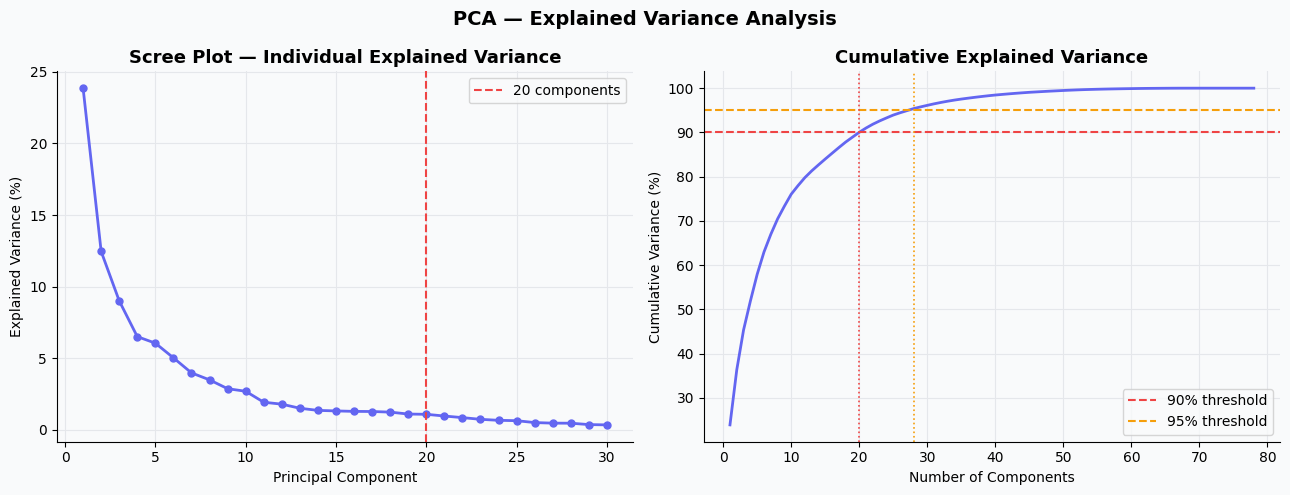

✓ Saved: 06_pca_scree.png


In [7]:
# Scree plot — visualizes the variance explained by each component
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: individual explained variance (elbow plot)
axes[0].plot(range(1, 31), pca_full.explained_variance_ratio_[:30] * 100,
             'o-', color='#6366f1', linewidth=2, markersize=5)
axes[0].axvline(n_90, color=PHISHING_COLOR, linestyle='--', linewidth=1.5,
                label=f'{n_90} components')
axes[0].set_title('Scree Plot — Individual Explained Variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].legend()

# Right: cumulative explained variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100,
             color='#6366f1', linewidth=2)
axes[1].axhline(90, color=PHISHING_COLOR, linestyle='--',
                linewidth=1.5, label='90% threshold')
axes[1].axhline(95, color='#f59e0b', linestyle='--',
                linewidth=1.5, label='95% threshold')
axes[1].axvline(n_90, color=PHISHING_COLOR, linestyle=':',  linewidth=1.2)
axes[1].axvline(n_95, color='#f59e0b',      linestyle=':',  linewidth=1.2)
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

fig.suptitle('PCA — Explained Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/06_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: 06_pca_scree.png')

In [8]:
# Apply PCA retaining 90% variance
pca      = PCA(n_components=n_90)
X_pca    = pca.fit_transform(X_scaled)

print(f'✓ PCA applied')
print(f'  Features before : {X_scaled.shape[1]}')
print(f'  Components after : {X_pca.shape[1]}')
print(f'  Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  Dimensionality reduction: {(1 - X_pca.shape[1]/X_scaled.shape[1])*100:.1f}%')

✓ PCA applied
  Features before : 78
  Components after : 20
  Variance retained: 90.01%
  Dimensionality reduction: 74.4%


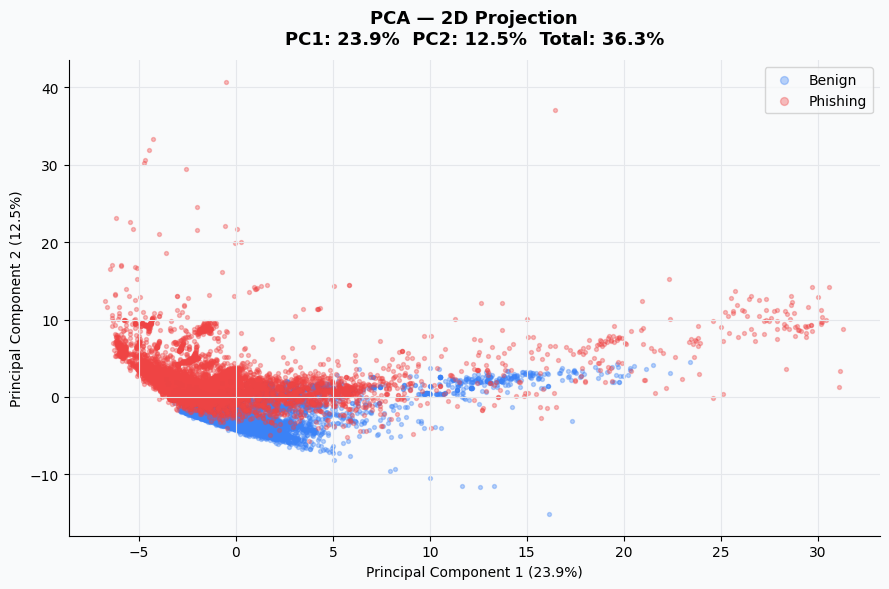

✓ Saved: 07_pca_2d_scatter.png


In [9]:
# 2D PCA scatter — visualize class separability
pca_2d   = PCA(n_components=2)
X_2d     = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))

scatter_b = ax.scatter(X_2d[y==0, 0], X_2d[y==0, 1],
                        c=BENIGN_COLOR,   alpha=0.35, s=8,  label='Benign')
scatter_p = ax.scatter(X_2d[y==1, 0], X_2d[y==1, 1],
                        c=PHISHING_COLOR, alpha=0.35, s=8,  label='Phishing')

ax.set_title(
    f'PCA — 2D Projection\n'
    f'PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%  '
    f'PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%  '
    f'Total: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%',
    pad=12
)
ax.set_xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/07_pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 07_pca_2d_scatter.png')

## 4. Classification — 3 Models × 3 Splits

Each model is trained and evaluated at three train/test splits.  
Results are logged to MongoDB after every run.

In [10]:
MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'               : SVC(kernel='rbf', random_state=42),
}

SPLITS = [
    (0.70, '70/30'),
    (0.80, '80/20'),
    (0.90, '90/10'),
]

# Store all results for the master table
results = []

print('Starting training runs...\n')
print(f'{"Model":<22} {"Split":<8} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('─' * 62)

for train_size, split_label in SPLITS:
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y, train_size=train_size, random_state=42, stratify=y
    )

    for model_name, model in MODELS.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        cm   = confusion_matrix(y_test, y_pred).tolist()

        # Log to MongoDB
        runs_col.insert_one({
            'model'      : model_name,
            'language'   : 'python',
            'split'      : split_label,
            'train_size' : train_size,
            'accuracy'   : round(acc,  4),
            'precision'  : round(prec, 4),
            'recall'     : round(rec,  4),
            'f1'         : round(f1,   4),
            'confusion_matrix': cm,
            'timestamp'  : datetime.datetime.utcnow()
        })

        results.append({
            'Model': model_name, 'Split': split_label,
            'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1,
            'CM': cm
        })

        print(f'{model_name:<22} {split_label:<8} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f}')

    print()

print('✓ All runs complete and logged to MongoDB')

Starting training runs...

Model                  Split        Acc    Prec     Rec      F1
──────────────────────────────────────────────────────────────
LogisticRegression     70/30     0.9343  0.9300  0.9384  0.9342
RandomForest           70/30     0.9764  0.9782  0.9742  0.9762
SVM                    70/30     0.9638  0.9727  0.9538  0.9632

LogisticRegression     80/20     0.9305  0.9237  0.9375  0.9305
RandomForest           80/20     0.9791  0.9802  0.9776  0.9789
SVM                    80/20     0.9629  0.9723  0.9524  0.9623

LogisticRegression     90/10     0.9218  0.9133  0.9307  0.9219
RandomForest           90/10     0.9777  0.9744  0.9810  0.9777
SVM                    90/10     0.9609  0.9657  0.9552  0.9604

✓ All runs complete and logged to MongoDB


## 5. Master Results Table

In [11]:
results_df = pd.DataFrame(results).drop(columns=['CM'])
results_df[['Accuracy','Precision','Recall','F1']] = (
    results_df[['Accuracy','Precision','Recall','F1']].round(4)
)

print('── Master Results Table ────────────────────────')
print(results_df.to_string(index=False))

# Best overall model
best = results_df.loc[results_df['F1'].idxmax()]
print(f'\nBest model by F1: {best["Model"]} at {best["Split"]} split')
print(f'  F1={best["F1"]:.4f}  Accuracy={best["Accuracy"]:.4f}  Recall={best["Recall"]:.4f}')

── Master Results Table ────────────────────────
             Model Split  Accuracy  Precision  Recall     F1
LogisticRegression 70/30    0.9343     0.9300  0.9384 0.9342
      RandomForest 70/30    0.9764     0.9782  0.9742 0.9762
               SVM 70/30    0.9638     0.9727  0.9538 0.9632
LogisticRegression 80/20    0.9305     0.9237  0.9375 0.9305
      RandomForest 80/20    0.9791     0.9802  0.9776 0.9789
               SVM 80/20    0.9629     0.9723  0.9524 0.9623
LogisticRegression 90/10    0.9218     0.9133  0.9307 0.9219
      RandomForest 90/10    0.9777     0.9744  0.9810 0.9777
               SVM 90/10    0.9609     0.9657  0.9552 0.9604

Best model by F1: RandomForest at 80/20 split
  F1=0.9789  Accuracy=0.9791  Recall=0.9776


## 6. Confusion Matrices — Best Split (80/20)

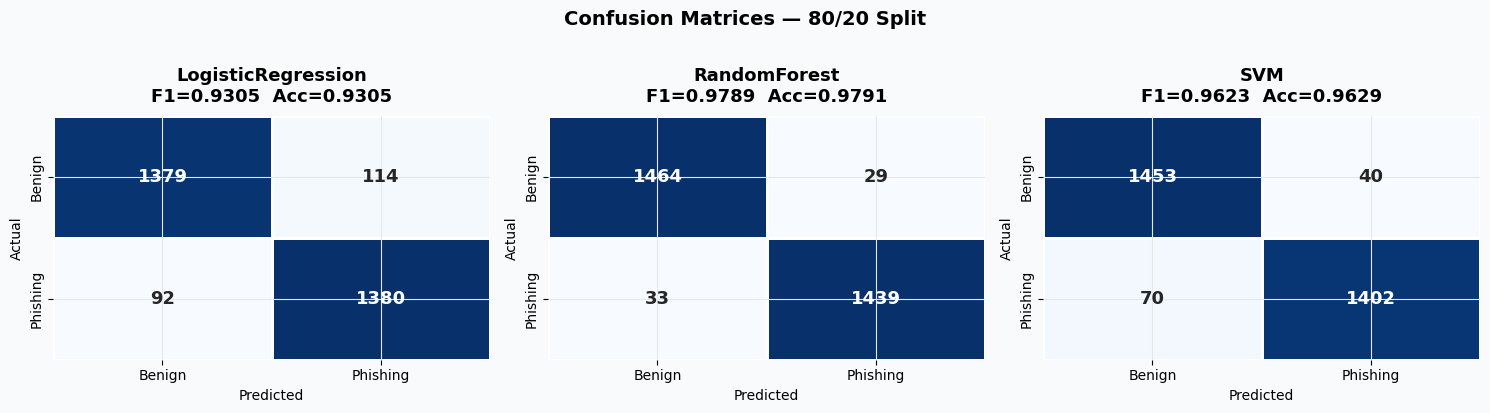

✓ Saved: 08_confusion_matrices.png


In [12]:
# Re-run 80/20 split to generate confusion matrix charts
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, train_size=0.80, random_state=42, stratify=y
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, model) in zip(axes, MODELS.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    # Normalize for percentage display
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        cmap='Blues', ax=ax,
        xticklabels=['Benign', 'Phishing'],
        yticklabels=['Benign', 'Phishing'],
        linewidths=1, linecolor='white',
        cbar=False, annot_kws={'size': 13, 'weight': 'bold'}
    )

    f1  = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{model_name}\nF1={f1:.4f}  Acc={acc:.4f}', pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices — 80/20 Split', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 08_confusion_matrices.png')

## 7. Feature Importance — Random Forest

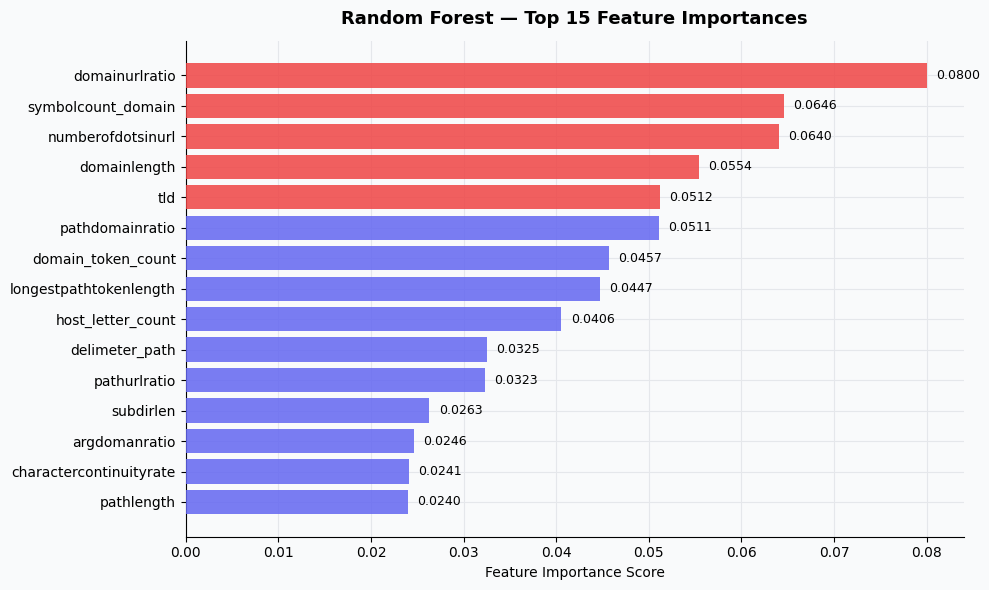

Top 15 features by importance:
domainurlratio             0.0800
symbolcount_domain         0.0646
numberofdotsinurl          0.0640
domainlength               0.0554
tld                        0.0512
pathdomainratio            0.0511
domain_token_count         0.0457
longestpathtokenlength     0.0447
host_letter_count          0.0406
delimeter_path             0.0325
pathurlratio               0.0323
subdirlen                  0.0263
argdomanratio              0.0246
charactercontinuityrate    0.0241
pathlength                 0.0240
✓ Saved: 09_feature_importance.png


In [13]:
# Random Forest gives feature importance scores for the PCA components.
# We also train on the original scaled features to get raw feature importance.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, train_size=0.80, random_state=42, stratify=y
)

rf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_raw.fit(X_train_raw, y_train_raw)

importances = pd.Series(rf_raw.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#ef4444' if i < 5 else '#6366f1' for i in range(len(top_features))]

ax.barh(range(len(top_features)), top_features.values[::-1],
        color=colors[::-1], alpha=0.85, zorder=3)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index[::-1], fontsize=10)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Random Forest — Top 15 Feature Importances', pad=12)

# Annotate values
for i, val in enumerate(top_features.values[::-1]):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features by importance:')
print(top_features.round(4).to_string())
print('✓ Saved: 09_feature_importance.png')

## 8. Split Comparison Chart

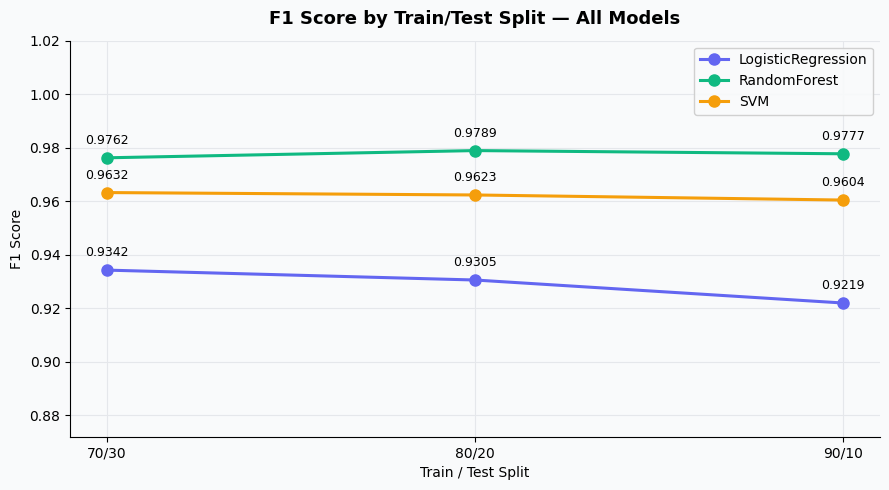

✓ Saved: 10_split_comparison.png


In [14]:
# Show how F1 changes across splits for each model
split_labels = ['70/30', '80/20', '90/10']
model_names  = list(MODELS.keys())
colors_model = ['#6366f1', '#10b981', '#f59e0b']

fig, ax = plt.subplots(figsize=(9, 5))

for model_name, color in zip(model_names, colors_model):
    f1_scores = [
        results_df[(results_df['Model'] == model_name) &
                   (results_df['Split'] == s)]['F1'].values[0]
        for s in split_labels
    ]
    ax.plot(split_labels, f1_scores, 'o-', color=color,
            linewidth=2.2, markersize=8, label=model_name)
    for x, y_val in zip(split_labels, f1_scores):
        ax.annotate(f'{y_val:.4f}', (x, y_val),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)

ax.set_title('F1 Score by Train/Test Split — All Models', pad=12)
ax.set_xlabel('Train / Test Split')
ax.set_ylabel('F1 Score')
ax.legend(framealpha=0.9)
ax.set_ylim(results_df['F1'].min() - 0.05, 1.02)

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/10_split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 10_split_comparison.png')

## 9. MongoDB Results Query

Pull all Python run results from MongoDB — confirms logging worked  
and provides the data source for the R comparison in `r/classifiers.R`.

In [15]:
# Query all Python runs sorted by F1
python_runs = list(
    runs_col.find(
        {'language': 'python', 'f1': {'$ne': None}},
        {'_id': 0, 'model': 1, 'split': 1,
         'accuracy': 1, 'precision': 1, 'recall': 1, 'f1': 1}
    ).sort('f1', -1)
)

mongo_df = pd.DataFrame(python_runs)
print('── MongoDB: Python Run Results (sorted by F1) ──')
print(mongo_df.to_string(index=False))

── MongoDB: Python Run Results (sorted by F1) ──
             model split  accuracy  precision  recall     f1
      RandomForest 80/20    0.9791     0.9802  0.9776 0.9789
      RandomForest 90/10    0.9777     0.9744  0.9810 0.9777
      RandomForest 70/30    0.9764     0.9782  0.9742 0.9762
               SVM 70/30    0.9638     0.9727  0.9538 0.9632
               SVM 80/20    0.9629     0.9723  0.9524 0.9623
               SVM 90/10    0.9609     0.9657  0.9552 0.9604
LogisticRegression 70/30    0.9343     0.9300  0.9384 0.9342
LogisticRegression 80/20    0.9305     0.9237  0.9375 0.9305
LogisticRegression 90/10    0.9218     0.9133  0.9307 0.9219


In [16]:
# Average F1 per model across all splits
avg_f1 = mongo_df.groupby('model')['f1'].mean().sort_values(ascending=False).round(4)
print('── Average F1 by Model (all splits) ────────────')
print(avg_f1.to_string())

── Average F1 by Model (all splits) ────────────
model
RandomForest          0.9776
SVM                   0.9620
LogisticRegression    0.9289


## 10. Classification Report — Best Model

In [17]:
# Full sklearn classification report for the best model at 80/20
best_model_name = avg_f1.idxmax()
best_model      = MODELS[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, train_size=0.80, random_state=42, stratify=y
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f'── Full Classification Report: {best_model_name} (80/20) ──')
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Phishing']))

print('Cybersecurity note:')
print('  Recall is the most critical metric for phishing detection.')
print('  A missed phishing URL (false negative) that reaches a user')
print('  is far more dangerous than a false alarm (false positive).')

── Full Classification Report: RandomForest (80/20) ──
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      1493
    Phishing       0.98      0.98      0.98      1472

    accuracy                           0.98      2965
   macro avg       0.98      0.98      0.98      2965
weighted avg       0.98      0.98      0.98      2965

Cybersecurity note:
  Recall is the most critical metric for phishing detection.
  A missed phishing URL (false negative) that reaches a user
  is far more dangerous than a false alarm (false positive).


---
## Summary

| Model | Best Split | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Logistic Regression | *70/30* | *93.43%* | *0.93* | *0.9384* | *0.9342* |
| Random Forest | *80/20* | *97.91%* | *0.9802* | *0.9776* | *0.9789* |
| SVM | *70/30* | *96.38%* | *0.9727* | *0.9538* | *0.9632* |

**PCA Summary:**  
- Features before: 78  
- Components after (90% variance): *20*  
- Dimensionality reduction: *74.4*%  

**Next:** `r/pca_analysis.R` and `r/classifiers.R` — replicate PCA and top 2 models in R.